# Regression Coefficient Plot: Education Indicators → Crude Death Rate

**Research question:** Which education indicators most strongly explain crude death rate, stratified by GDP level?

**Approach:** Split countries at the median normalized GDP per capita into Low GDP and High GDP groups. Within each group, run OLS on education predictors only — GDP is handled by the stratification itself, not as a covariate.

**Model:** OLS with HC3 robust SEs | all variables normalized to [0, 1], so coefficients are directly comparable in magnitude.

| Role | Variables |
|------|-----------|
| Outcome | Crude death rate |
| Stratification | GDP per capita (median split → Low / High) |
| Education predictors | Bachelor's attainment, Youth NEET, School life exp. (tertiary), Tertiary enrolment |

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Frida_Kahlo_Normalized_Clean.csv')

col_map = {
    'Country': 'country',
    'Year': 'year',
    'GDP per capita, PPP (constant 2021 international $)': 'gdp_pc',
    'Access to electricity (% of population)': 'electricity',
    'Educational attainment, at least Bachelor\'s or equivalent, population 25+, total (%) (cumulative)': 'bachelors',
    'Share of youth not in education, employment or training, total (% of youth population)  (modeled ILO estimate)': 'neet',
    'School life expectancy, tertiary, both sexes (years)': 'school_life_tertiary',
    'Enrolment in tertiary education, all programmes, both sexes (number)': 'tertiary_enrolment',
    'Death rate, crude (per 1,000 people)': 'death_rate'
}

df = df.rename(columns=col_map)

model_vars = ['country', 'year', 'gdp_pc', 'electricity',
              'bachelors', 'neet', 'school_life_tertiary', 'tertiary_enrolment', 'death_rate']

df_model = df[model_vars].dropna()
print(f'Observations after dropping NaN: {len(df_model)}')
print(f'Countries: {df_model["country"].nunique()}')
df_model.describe()

Observations after dropping NaN: 453
Countries: 112


,year,gdp_pc,electricity,bachelors,neet,school_life_tertiary,tertiary_enrolment,death_rate
count,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000
mean,2015.609272,0.214936,0.914503,0.386012,0.298852,0.359234,0.034471,0.468195
std,1.972062,0.182378,0.215868,0.210542,0.175021,0.200371,0.100493,0.202523
min,2012.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014.000000,0.075163,0.977804,0.224734,0.155758,0.206510,0.003760,0.330871
50%,2016.000000,0.178189,1.000000,0.375017,0.279028,0.389473,0.007561,0.435388
75%,2017.000000,0.326543,1.000000,0.552525,0.438004,0.488150,0.028939,0.581672
max,2019.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
gdp_median = df_model['gdp_pc'].median()
df_low  = df_model[df_model['gdp_pc'] <  gdp_median].copy()
df_high = df_model[df_model['gdp_pc'] >= gdp_median].copy()

print(f"Median normalized GDP: {gdp_median:.3f}")
print(f"Low GDP  -- obs: {len(df_low)},  countries: {df_low['country'].nunique()}")
print(f"High GDP -- obs: {len(df_high)}, countries: {df_high['country'].nunique()}")

Median normalized GDP: 0.178
Low GDP  -- obs: 226,  countries: 65
High GDP -- obs: 227, countries: 48


In [5]:
# Education-only formula -- GDP handled by the group split, not as a covariate
edu_formula = (
    'death_rate ~ bachelors + neet + school_life_tertiary + tertiary_enrolment'
)

model_low  = smf.ols(edu_formula, data=df_low).fit(cov_type='HC3')
model_high = smf.ols(edu_formula, data=df_high).fit(cov_type='HC3')

print("=== LOW GDP ===")
print(model_low.summary())
print("\n=== HIGH GDP ===")
print(model_high.summary())

=== LOW GDP ===
                            OLS Regression Results                            
Dep. Variable:             death_rate   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     4.410
Date:                Thu, 30 Apr 2026   Prob (F-statistic):            0.00189
Time:                        13:26:51   Log-Likelihood:                 61.126
No. Observations:                 226   AIC:                            -112.3
Df Residuals:                     221   BIC:                            -95.15
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept       

In [6]:
def extract_results(model, group_label):
    res = pd.DataFrame({
        'variable':    model.params.index,
        'coefficient': model.params.values,
        'ci_lower':    model.conf_int()[0].values,
        'ci_upper':    model.conf_int()[1].values,
        'p_value':     model.pvalues.values,
        'std_err':     model.bse.values,
        'gdp_group':   group_label
    })
    return res[res['variable'] != 'Intercept'].copy()

label_map = {
    'bachelors':            "Bachelor's attainment",
    'neet':                 'Youth NEET',
    'school_life_tertiary': 'School life exp. (tertiary)',
    'tertiary_enrolment':   'Tertiary enrolment'
}

res_low  = extract_results(model_low,  'Low GDP')
res_high = extract_results(model_high, 'High GDP')
results  = pd.concat([res_low, res_high], ignore_index=True)

results['label']       = results['variable'].map(label_map)
results['significant'] = results['p_value'] < 0.05

display(results[['gdp_group', 'label', 'coefficient', 'ci_lower', 'ci_upper', 'p_value', 'significant']])

,gdp_group,label,coefficient,ci_lower,ci_upper,p_value,significant
0,Low GDP,Bachelor's attainment,0.203771,-0.024140,0.431682,0.079711,False
1,Low GDP,Youth NEET,-0.210534,-0.387373,-0.033695,0.019627,True
2,Low GDP,School life exp. (tertiary),0.016939,-0.247222,0.281100,0.899984,False
3,Low GDP,Tertiary enrolment,-0.148183,-0.305809,0.009443,0.065395,False
4,High GDP,Bachelor's attainment,-0.238911,-0.434322,-0.043500,0.016563,True
5,High GDP,Youth NEET,-0.308017,-0.641611,0.025578,0.070344,False
6,High GDP,School life exp. (tertiary),0.304796,0.092010,0.517582,0.004993,True
7,High GDP,Tertiary enrolment,-0.028995,-0.174746,0.116757,0.696612,False


In [7]:
results.to_csv('regression_coefficients.csv', index=False)
print('Saved: regression_coefficients.csv')
print()
print('Columns: gdp_group | label | coefficient | ci_lower | ci_upper | p_value | significant')
print('8 rows total: 4 education vars x 2 GDP groups')
print('Use gdp_group to split panels in Tableau.')

Saved: regression_coefficients.csv

Columns: gdp_group | label | coefficient | ci_lower | ci_upper | p_value | significant
8 rows total: 4 education vars x 2 GDP groups
Use gdp_group to split panels in Tableau.


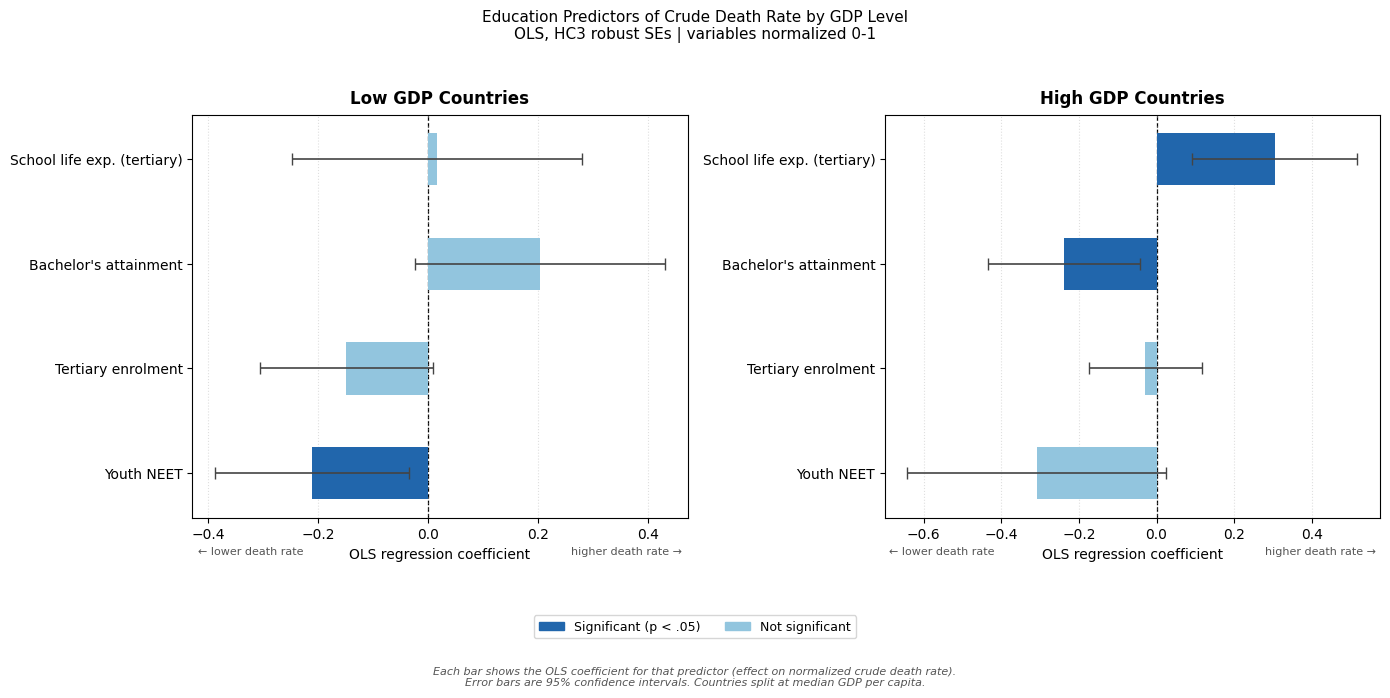

Saved: coef_plot.png


In [8]:
var_order = ['neet', 'tertiary_enrolment', 'bachelors', 'school_life_tertiary']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, group in zip(axes, ['Low GDP', 'High GDP']):
    grp = (results[results['gdp_group'] == group]
           .set_index('variable')
           .reindex(var_order)
           .reset_index())

    y_pos = list(range(len(grp)))
    colors = ['#2166ac' if s else '#92c5de' for s in grp['significant']]

    ax.barh(y_pos, grp['coefficient'], color=colors, height=0.5, zorder=2)

    xerr_lo = (grp['coefficient'] - grp['ci_lower']).values
    xerr_hi = (grp['ci_upper'] - grp['coefficient']).values
    ax.errorbar(
        grp['coefficient'], y_pos,
        xerr=[xerr_lo, xerr_hi],
        fmt='none', color='#444444', linewidth=1.2, capsize=4, zorder=3
    )

    ax.axvline(0, color='black', linewidth=0.9, linestyle='--', zorder=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp['label'].tolist(), fontsize=10)

    xlim = ax.get_xlim()
    ax.text(xlim[0] + 0.01, -0.75, u'← lower death rate',
            fontsize=8, color='#555555', va='center', ha='left')
    ax.text(xlim[1] - 0.01, -0.75, u'higher death rate →',
            fontsize=8, color='#555555', va='center', ha='right')

    ax.set_xlabel('OLS regression coefficient', fontsize=10)
    ax.set_title(f'{group} Countries', fontsize=12, pad=8, fontweight='bold')
    ax.grid(axis='x', linestyle=':', alpha=0.4, zorder=0)

legend_handles = [
    mpatches.Patch(color='#2166ac', label='Significant (p < .05)'),
    mpatches.Patch(color='#92c5de', label='Not significant'),
]
legend = fig.legend(
    handles=legend_handles, fontsize=9,
    loc='upper center', bbox_to_anchor=(0.5, -0.06),
    ncol=2, frameon=True
)

fig.suptitle(
    'Education Predictors of Crude Death Rate by GDP Level\n'
    'OLS, HC3 robust SEs | variables normalized 0-1',
    fontsize=11, y=1.03
)

# Caption sits well below the legend with no overlap
fig.text(
    0.5, -0.20,
    'Each bar shows the OLS coefficient for that predictor (effect on normalized crude death rate).\n'
    'Error bars are 95% confidence intervals. Countries split at median GDP per capita.',
    ha='center', fontsize=8, color='#555555', style='italic'
)

plt.tight_layout()
plt.savefig('coef_plot.png', dpi=150, bbox_inches='tight', bbox_extra_artists=(legend,))
plt.show()
print('Saved: coef_plot.png')